In [44]:
import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd
from MDAnalysis import transformations
from MDAnalysis.analysis.rdf import InterRDF
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import mdtraj as mdtraj
import pandas as pd

In [45]:
## Convert ase trajectory
! rm wat_nvt_mace.pdb
! ase convert ../data/traj_wat/nvt_mace/wat300.traj wat_nvt_mace.pdb
! rm wat_nvt_2l_a_wpS_medium.pdb
! ase convert ../data/traj_wat/nvt_2l_a_wpS_medium/wat300.traj wat_nvt_2l_a_wpS_medium.pdb

100%|██████████| 1716/1716 [00:00<00:00, 13967.94it/s]

Self Diffusion: 0.45545861270924287 A^2/ps
Self Diffusion: 4.554586127092429e-09 m^2/s


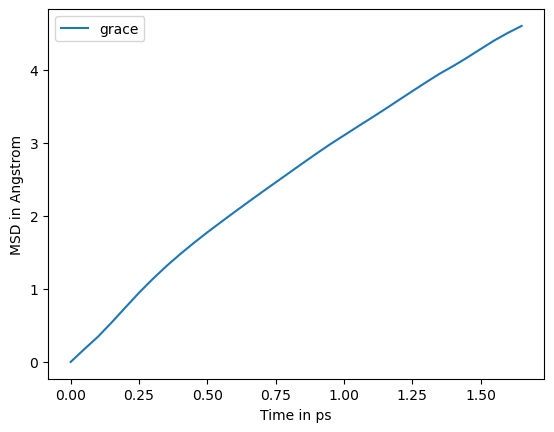

In [46]:

u_2l_a_wpS_medium = mda.Universe("wat_nvt_2l_a_wpS_medium.pdb")
atoms = u_2l_a_wpS_medium.atoms
transform = mda.transformations.NoJump(atoms)
u_2l_a_wpS_medium.trajectory.add_transformations(transform)
MSD_mm = msd.EinsteinMSD(u_2l_a_wpS_medium, select="all", msd_type="xyz", fft=True)
MSD_mm.run(step=1)

result_mm = MSD_mm.results.timeseries
msd_all = result_mm
nframes = MSD_mm.n_frames
timestep = 0.05  # in ps,  this needs to be the actual time between frames
lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
lag = lagtimes
# plot the actual MSD
plt.plot(lagtimes, result_mm, label='grace')
plt.ylabel("MSD in Angstrom")
plt.xlabel("Time in ps")
#plt.show()

#linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
linear_model = linregress(lagtimes, result_mm)
slope = linear_model.slope
error = linear_model.stderr
D = slope / 6
print(f"Self Diffusion: {D} A^2/ps")
print(f"Self Diffusion: {D*10**-8} m^2/s")
diffusion = D * 10**-8

#ANI diffusion
plt.legend()
plt.show()

100%|██████████| 1716/1716 [00:00<00:00, 15617.24it/s]

Self Diffusion: 0.39628100564565094 A^2/ps
Self Diffusion: 3.96281005645651e-09 m^2/s


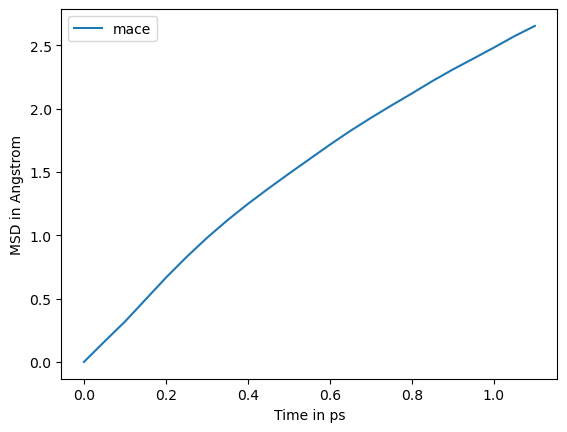

In [47]:

u_mace = mda.Universe("wat_nvt_mace.pdb")
atoms = u_mace.atoms
transform = mda.transformations.NoJump(atoms)
u_mace.trajectory.add_transformations(transform)
MSD_mm = msd.EinsteinMSD(u_mace, select="all", msd_type="xyz", fft=True)
MSD_mm.run(step=1)

result_mm = MSD_mm.results.timeseries
msd_all = result_mm
nframes = MSD_mm.n_frames
timestep = 0.05  # in ps,  this needs to be the actual time between frames
lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
lag = lagtimes
# plot the actual MSD
plt.plot(lagtimes, result_mm, label='mace')
plt.ylabel("MSD in Angstrom")
plt.xlabel("Time in ps")
#plt.show()

#linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
linear_model = linregress(lagtimes, result_mm)
slope = linear_model.slope
error = linear_model.stderr
D = slope / 6
print(f"Self Diffusion: {D} A^2/ps")
print(f"Self Diffusion: {D*10**-8} m^2/s")
diffusion = D * 10**-8

#ANI diffusion
plt.legend()
plt.show()

100%|██████████| 1716/1716 [00:00<00:00, 11580.14it/s]

Self Diffusion: 0.45545861270924287 A^2/ps
Self Diffusion: 4.554586127092429e-09 m^2/s


100%|██████████| 1716/1716 [00:00<00:00, 15305.99it/s]

Self Diffusion: 0.39628100564565094 A^2/ps
Self Diffusion: 3.96281005645651e-09 m^2/s


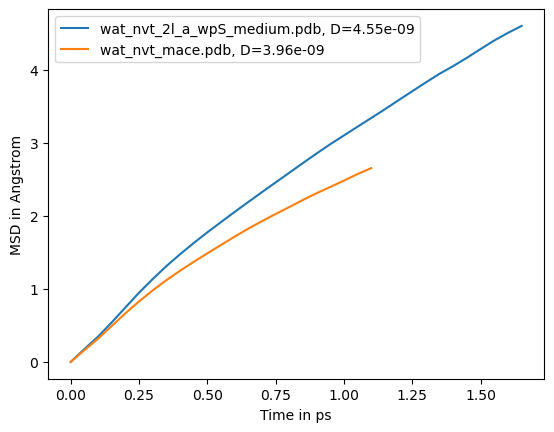

In [48]:
models=["wat_nvt_2l_a_wpS_medium.pdb", "wat_nvt_mace.pdb"]
for model in models:
    universe = mda.Universe(model)
    atoms = universe.atoms
    transform = mda.transformations.NoJump(atoms)
    universe.trajectory.add_transformations(transform)
    MSD_mm = msd.EinsteinMSD(universe, select="all", msd_type="xyz", fft=True)
    MSD_mm.run(step=1)

    result_mm = MSD_mm.results.timeseries
    msd_all = result_mm
    nframes = MSD_mm.n_frames
    timestep = 0.05  # in ps,  this needs to be the actual time between frames
    lagtimes = np.arange(nframes) * timestep  # make the lag-time axis
    lag = lagtimes
    # plot the actual MSD
    #plt.show()

    #linear_model = linregress(lagtimes[500:-100], result_mm[500:-100])
    linear_model = linregress(lagtimes, result_mm)
    slope = linear_model.slope
    error = linear_model.stderr
    D = slope / 6
    print(f"Self Diffusion: {D} A^2/ps")
    print(f"Self Diffusion: {D*10**-8} m^2/s")
    diffusion = D * 10**-8
    plt.plot(lagtimes, result_mm, label=f'{model}, D={diffusion:.2e}')
    plt.ylabel("MSD in Angstrom")
    plt.xlabel("Time in ps")

    #ANI diffusion
plt.legend()
plt.show()